# LambdaMART on MSLR
### Learning to Rank — Lambda Gradient Approach with GBDT
---
**Dataset**: MSLR 10k  
**Model**: LambdaMART with Optimal Line Search  
**Gradients**: Lambda(λ)  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **LambdaMART**. It uses the exact same $\lambda$-gradients as LambdaRank, but instead of using a neural network, it trains **Gradient Boosted Decision Trees (GBDT)**.

This notebook uses the **Optimal Line Search** for finding the tree weights ($\alpha$). We use a path-following algorithm that directly maximizes NDCG by finding exactly where the rank order of documents swaps.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | How LambdaMART and Optimal Line Search works |
| 5    | Model definition using `ltr.lambdamart.LambdaMART` |
| 6    | Training on Fold 1 |
| 7    | Optimizing the tree complexity |


## Step 1 · Colab Setup & Package Installation

In [ ]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/Phase2_3_Learning_to_Rank", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Phase2_3_Learning_to_Rank")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

## Downloading the dataset

In [ ]:
import gdown
drive_url = "https://drive.google.com/file/d/105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY/view?usp=drive_link"
# Download the file
gdown.download(drive_url, output="mslr.zip", fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY
From (redirected): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY&confirm=t&uuid=921050d5-ff32-43cf-b7ad-617b6022d96b
To: /content/mslr.zip
100%|██████████| 1.45G/1.45G [00:17<00:00, 83.2MB/s]


'mslr.zip'

## Extraction

In [ ]:
# ── Extract MSLR 10k dataset ────────────────────────────────────────────────────
import zipfile, os

ZIP_PATH  = "/content/mslr.zip"
DATA_PATH = "/content/MSLR"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Step 3 · Imports & Configuration

In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data_mslr  import load_fold
from ltr.lambdamart import LambdaMART
from ltr.train      import set_seed
from ltr.metrics    import mean_ndcg
from ltr.evaluate   import cross_fold_eval_lambdamart

# ── Global config ─────────────────────────────────────────────────────────────
DATA_PATH = "/content"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)

## Step 4 · Data Loading

In [ ]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)


  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score


## Step 5 · How LambdaMART & Optimal Line Search Works

LambdaMART replaces the neural network of LambdaRank with an ensemble of **Decision Trees**.
At each iteration $t$, we:
1. We start with base weak ranker which predicts **0** as ouput for every document.
2. Compute the $\lambda_i$ gradients and hessians $w_i$ for all documents using our current model scores $S_t$.
3. Fit a `DecisionTreeRegressor` to predict pseudo-residuals $y_i = -\lambda_i / w_i$ with sample weights $w_i$.
4. Find the optimal combination weight $\alpha$ using an **Exact Line Search**.
5. Update the scores: $S_{t+1} = S_t + \alpha \cdot \text{tree}(X)$

### The Optimal Line Search
Instead of guessing a learning rate (like $\eta=0.1$), we find the $\alpha$ that mathematically maximizes the NDCG.
Because NDCG only changes when documents **swap rank positions**, we can calculate the exact $\alpha$ where any two documents' scores will cross:
$$ S_i + \alpha P_i = S_j + \alpha P_j \implies \alpha = \frac{S_j - S_i}{P_i - P_j} $$

We collect all crossing points for all queries, sort them, and traverse them one by one. At each crossing, we swap the two documents and update the NDCG. Finally, we pick the $\alpha$ that gave the highest overall NDCG.

**Problem**:- Sometimes, more than one pair documents cross each other at crossing point.

**Solution**:-
***Jittering for Degeneracies-*** We add a microscopic random noise ($10^{-9}$) to the initial scores/predictions. This strictly guarantees that no two pairs of documents will ever cross at the same crossing point.

## Step 6 · Model Definition and Training (Fold 1)

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=20,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3954 | Val NDCG@10: 0.3980  <- best
Tree 002 | α*: 0.2316 | η·α*: 0.1158 | Train NDCG@10: 0.4083 | Val NDCG@10: 0.4098  <- best
Tree 003 | α*: 0.3286 | η·α*: 0.1643 | Train NDCG@10: 0.4134 | Val NDCG@10: 0.4148  <- best
Tree 004 | α*: 0.5140 | η·α*: 0.2570 | Train NDCG@10: 0.4201 | Val NDCG@10: 0.4205  <- best
Tree 005 | α*: 0.6795 | η·α*: 0.3398 | Train NDCG@10: 0.4269 | Val NDCG@10: 0.4235  <- best
Tree 006 | α*: 0.6607 | η·α*: 0.3303 | Train NDCG@10: 0.4358 | Val NDCG@10: 0.4303  <- best
Tree 007 | α*: 0.7204 | η·α*: 0.3602 | Train NDCG@10: 0.4417 | Val NDCG@10: 0.4334  <- best
Tree 008 | α*: 0.6362 | η·α*: 0.3181 | Train NDCG@10: 0.4466 | Val NDCG@10: 0.4362  <- best
Tree 009 | α*: 0.6648 | η·α*: 0.3324 | Train NDCG@10: 0.4508 | Val NDCG@10: 0.4382  <- best
Tree 010 | α*: 0.7352 | η·α*: 0.3676 | Train NDCG@10: 0.4558 | Val NDCG@10: 0.4422  <- best
Tree 011 | α*: 0.7202 | η·α*: 0.3601 | Train NDCG@10: 0.4594 | Val NDCG@10: 0.44

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(train_ndcgs, val_ndcgs, title="Training Curves"):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Find the best epoch
    best_epoch = np.argmax(val_ndcgs) + 1

    # Vertical dotted line for the best epoch
    ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.8,
               label=f'Best Epoch ({best_epoch})')

    # Plot both curves on the same Y-axis
    ax.plot(range(1, len(train_ndcgs) + 1), train_ndcgs,
            label='Train NDCG@10', color='tab:red', marker='o')
    ax.plot(range(1, len(val_ndcgs) + 1), val_ndcgs,
            label='Val NDCG@10', color='tab:blue', marker='s')

    ax.set_xlabel('Epochs')
    ax.set_ylabel('NDCG@10')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

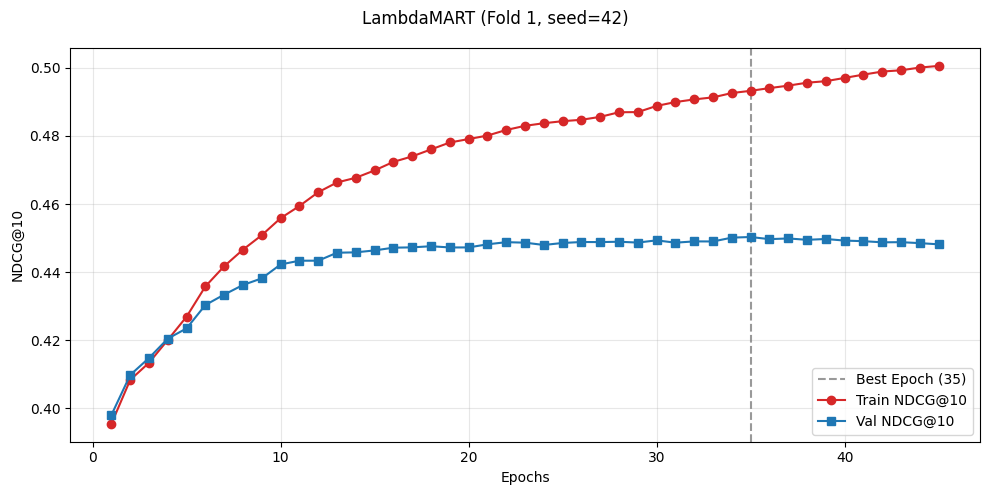

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (Fold 1, seed=42)")


## Key Takeaways:
- The model is overfitting. To reduce overfitting we can change the following hyperparameters.
  1. Reduce Learning Rate - more number of trees - increases smoothlyy - Reduces Overfitting.
  2. Increase min_samples_leaf or Decrease Max_depth - This will reduce the complexity of each tree.

## Next Steps:
- First i would like to try changing learning rate.

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.4322
  NDCG@3  : 0.4208
  NDCG@5  : 0.4277
  NDCG@10 : 0.4421


## Key Takeaways:
- The result is same as LambdaRank but it should perform better tham lambdaRank let us see by fien tuning the lambdaMart.

# Learning Rate = 0.1

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.1000 | η·α*: 0.0100 | Train NDCG@10: 0.3954 | Val NDCG@10: 0.3980  <- best
Tree 002 | α*: 0.0091 | η·α*: 0.0009 | Train NDCG@10: 0.4031 | Val NDCG@10: 0.4045  <- best
Tree 003 | α*: 0.0066 | η·α*: 0.0007 | Train NDCG@10: 0.4047 | Val NDCG@10: 0.4057  <- best
Tree 004 | α*: 0.0056 | η·α*: 0.0006 | Train NDCG@10: 0.4057 | Val NDCG@10: 0.4067  <- best
Tree 005 | α*: 0.0092 | η·α*: 0.0009 | Train NDCG@10: 0.4070 | Val NDCG@10: 0.4077  <- best
Tree 006 | α*: 0.0033 | η·α*: 0.0003 | Train NDCG@10: 0.4071 | Val NDCG@10: 0.4083  <- best
Tree 007 | α*: 0.0082 | η·α*: 0.0008 | Train NDCG@10: 0.4077 | Val NDCG@10: 0.4085  <- best
Tree 008 | α*: 0.0065 | η·α*: 0.0006 | Train NDCG@10: 0.4086 | Val NDCG@10: 0.4094  <- best
Tree 009 | α*: 0.0059 | η·α*: 0.0006 | Train NDCG@10: 0.4091 | Val NDCG@10: 0.4099  <- best
Tree 010 | α*: 0.0053 | η·α*: 0.0005 | Train NDCG@10: 0.4092 | Val NDCG@10: 0.4105  <- best
Tree 011 | α*: 0.0038 | η·α*: 0.0004 | Train NDCG@10: 0.4094 | Val NDCG@10: 0.41

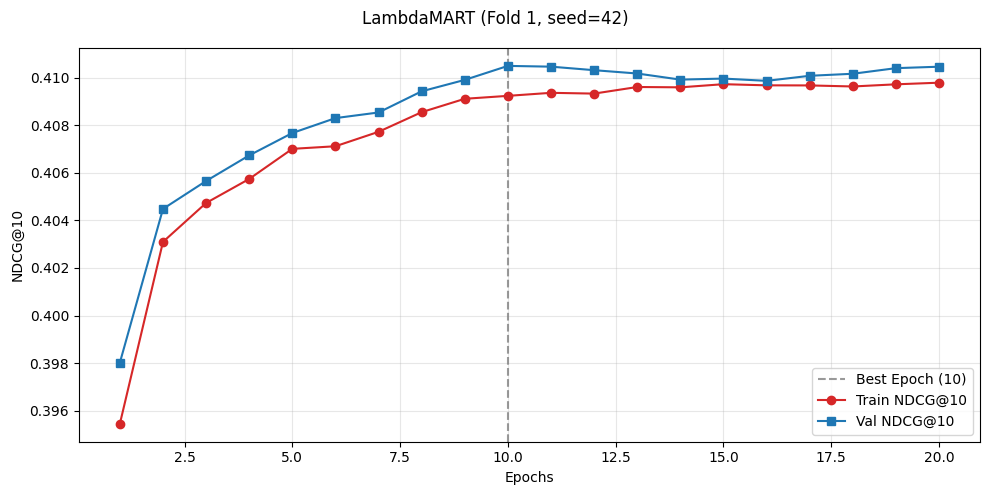

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (Fold 1, seed=42)")


## Key Takeaways:
- Overfitting is reduced but both the curves flattend out early this is underfitting. Let us increase lr.

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3928
  NDCG@3  : 0.3805
  NDCG@5  : 0.3852
  NDCG@10 : 0.4019


- Result is worse

# Learning Rate = 0.25

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.25,
    max_depth=6,
    min_samples_leaf=20,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.2500 | η·α*: 0.0625 | Train NDCG@10: 0.3954 | Val NDCG@10: 0.3980  <- best
Tree 002 | α*: 0.0949 | η·α*: 0.0237 | Train NDCG@10: 0.4054 | Val NDCG@10: 0.4061  <- best
Tree 003 | α*: 0.0578 | η·α*: 0.0144 | Train NDCG@10: 0.4078 | Val NDCG@10: 0.4088  <- best
Tree 004 | α*: 0.0434 | η·α*: 0.0109 | Train NDCG@10: 0.4088 | Val NDCG@10: 0.4104  <- best
Tree 005 | α*: 0.0345 | η·α*: 0.0086 | Train NDCG@10: 0.4090 | Val NDCG@10: 0.4105  <- best
Tree 006 | α*: 0.0367 | η·α*: 0.0092 | Train NDCG@10: 0.4094 | Val NDCG@10: 0.4103
Tree 007 | α*: 0.0283 | η·α*: 0.0071 | Train NDCG@10: 0.4098 | Val NDCG@10: 0.4103
Tree 008 | α*: 0.0031 | η·α*: 0.0008 | Train NDCG@10: 0.4098 | Val NDCG@10: 0.4104
Tree 009 | α*: 0.0756 | η·α*: 0.0189 | Train NDCG@10: 0.4102 | Val NDCG@10: 0.4102
Tree 010 | α*: 0.0015 | η·α*: 0.0004 | Train NDCG@10: 0.4102 | Val NDCG@10: 0.4102
Tree 011 | α*: 0.0016 | η·α*: 0.0004 | Train NDCG@10: 0.4102 | Val NDCG@10: 0.4103
Tree 012 | α*: 0.0012 | η·α*: 0.0003 | Tra

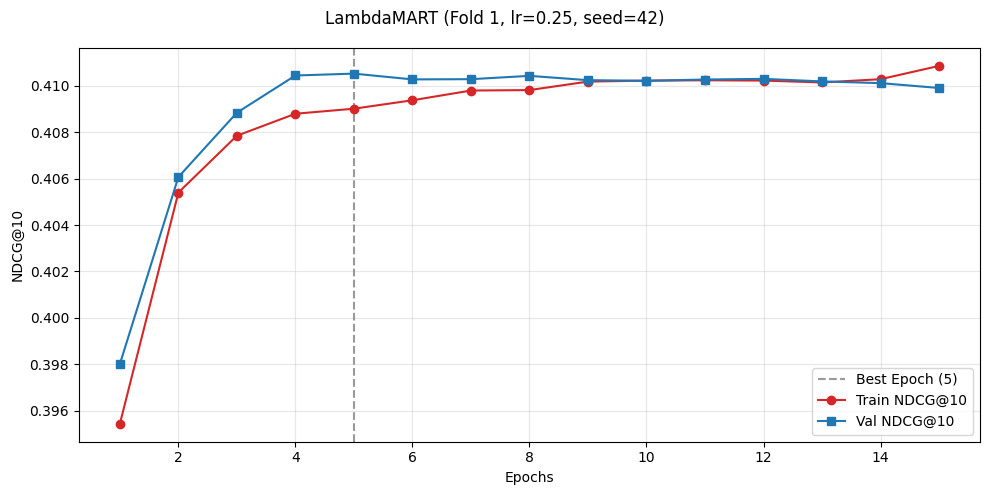

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (Fold 1, lr=0.25, seed=42)")


### Still the same problem

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3987
  NDCG@3  : 0.3808
  NDCG@5  : 0.3858
  NDCG@10 : 0.4023


## Key Takeaways:
- The problem still persists.

## Next Steps:
- First I would like to fine-tune tree complexity then i will find the best possible Learning Rate for that tree complexity.

## Step 7 · Optimizing the tree complexity(Max_depth and Min_samples_leaf)

- Using grid search to find best pair of max_depth and min_samples_leaf.

In [ ]:
import itertools
import pandas as pd

# Fixed at a middle learning rate for this pass (tuning depth/leaf as a pair first)
FIXED_LR = 0.5

max_depth_grid = [6]
min_samples_leaf_grid = [20, 50, 100]

results = []

for max_depth, min_samples_leaf in itertools.product(max_depth_grid, min_samples_leaf_grid):
    set_seed(42)

    model = LambdaMART(
        n_estimators=100,
        learning_rate=FIXED_LR,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        k=10,
        patience=10,
        use_optimal_line_search=True
    )

    best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        verbose=False
    )

    test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

    row = {
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "learning_rate": FIXED_LR,
    }
    for k in K_LIST:
        row[f"NDCG@{k}"] = test_ndcg[k]
    results.append(row)

    print(f"max_depth={max_depth:<2} | min_samples_leaf={min_samples_leaf:<4} | "
          + " | ".join(f"NDCG@{k}: {test_ndcg[k]:.4f}" for k in K_LIST))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=f"NDCG@10", ascending=False).reset_index(drop=True)

print("\nRanked by NDCG@10:")
print(results_df.to_string(index=False))

max_depth=6  | min_samples_leaf=20   | NDCG@1: 0.4215 | NDCG@3: 0.4150 | NDCG@5: 0.4199 | NDCG@10: 0.4351
max_depth=6  | min_samples_leaf=50   | NDCG@1: 0.4299 | NDCG@3: 0.4157 | NDCG@5: 0.4200 | NDCG@10: 0.4358
max_depth=6  | min_samples_leaf=100  | NDCG@1: 0.4406 | NDCG@3: 0.4204 | NDCG@5: 0.4261 | NDCG@10: 0.4404

Ranked by NDCG@10:
 max_depth  min_samples_leaf  learning_rate   NDCG@1   NDCG@3   NDCG@5  NDCG@10
         6               100            0.5 0.440614 0.420370 0.426075 0.440403
         6                50            0.5 0.429857 0.415737 0.420002 0.435840
         6                20            0.5 0.421543 0.415004 0.419875 0.435109


## Key Takeaways:
- As the minimum number of samples in leaf is increased NDCG is also increased because if it is low the tree will become complex and memorizes the training data which fails in capturing the general pattern and give worse results.
- I will try changing the Max_depth now. First I will try using 100 minimum no.of samples if it underfits then i will reduce the number.

## Max_depth = 5, Min_samples_leaf = 100

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=5,
    min_samples_leaf=100,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3882 | Val NDCG@10: 0.3938  <- best
Tree 002 | α*: 0.2749 | η·α*: 0.1375 | Train NDCG@10: 0.3987 | Val NDCG@10: 0.4019  <- best
Tree 003 | α*: 0.3371 | η·α*: 0.1685 | Train NDCG@10: 0.4031 | Val NDCG@10: 0.4049  <- best
Tree 004 | α*: 2.0496 | η·α*: 1.0248 | Train NDCG@10: 0.4082 | Val NDCG@10: 0.4100  <- best
Tree 005 | α*: 0.9408 | η·α*: 0.4704 | Train NDCG@10: 0.4159 | Val NDCG@10: 0.4160  <- best
Tree 006 | α*: 1.2942 | η·α*: 0.6471 | Train NDCG@10: 0.4276 | Val NDCG@10: 0.4257  <- best
Tree 007 | α*: 0.9574 | η·α*: 0.4787 | Train NDCG@10: 0.4337 | Val NDCG@10: 0.4272  <- best
Tree 008 | α*: 0.6805 | η·α*: 0.3403 | Train NDCG@10: 0.4387 | Val NDCG@10: 0.4307  <- best
Tree 009 | α*: 0.8627 | η·α*: 0.4313 | Train NDCG@10: 0.4416 | Val NDCG@10: 0.4330  <- best
Tree 010 | α*: 1.2024 | η·α*: 0.6012 | Train NDCG@10: 0.4447 | Val NDCG@10: 0.4330
Tree 011 | α*: 0.7779 | η·α*: 0.3889 | Train NDCG@10: 0.4475 | Val NDCG@10: 0.4348  <- be

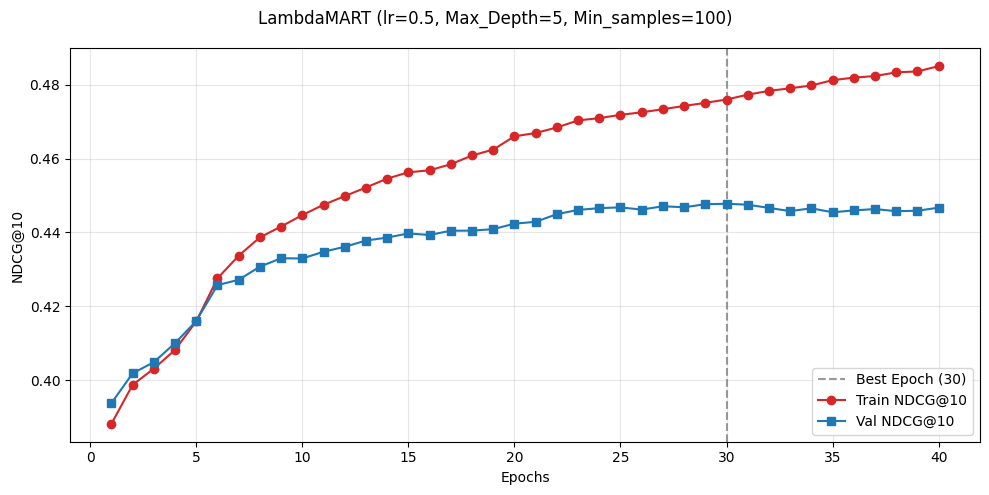

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=5, Min_samples=100)")


## Key Takeaways:
- The model is still overfitting. If we reduce the `min_samples_leaf` it will just overfit more. So, i will just try reducing the max_depth.

## Results on Test data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=100)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=100)
──────────────────────────────
  NDCG@1  : 0.4278
  NDCG@3  : 0.4142
  NDCG@5  : 0.4178
  NDCG@10 : 0.4350


## Max_depth = 4, Min_samples_leaf = 100

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=4,
    min_samples_leaf=100,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3737 | Val NDCG@10: 0.3771  <- best
Tree 002 | α*: 0.1634 | η·α*: 0.0817 | Train NDCG@10: 0.3923 | Val NDCG@10: 0.3987  <- best
Tree 003 | α*: 0.3578 | η·α*: 0.1789 | Train NDCG@10: 0.3950 | Val NDCG@10: 0.3998  <- best
Tree 004 | α*: 0.2964 | η·α*: 0.1482 | Train NDCG@10: 0.3968 | Val NDCG@10: 0.4021  <- best
Tree 005 | α*: 0.9972 | η·α*: 0.4986 | Train NDCG@10: 0.4020 | Val NDCG@10: 0.4062  <- best
Tree 006 | α*: 1.0678 | η·α*: 0.5339 | Train NDCG@10: 0.4103 | Val NDCG@10: 0.4142  <- best
Tree 007 | α*: 0.9432 | η·α*: 0.4716 | Train NDCG@10: 0.4205 | Val NDCG@10: 0.4225  <- best
Tree 008 | α*: 1.0837 | η·α*: 0.5419 | Train NDCG@10: 0.4280 | Val NDCG@10: 0.4267  <- best
Tree 009 | α*: 1.0233 | η·α*: 0.5116 | Train NDCG@10: 0.4328 | Val NDCG@10: 0.4326  <- best
Tree 010 | α*: 0.8609 | η·α*: 0.4304 | Train NDCG@10: 0.4363 | Val NDCG@10: 0.4343  <- best
Tree 011 | α*: 1.0482 | η·α*: 0.5241 | Train NDCG@10: 0.4384 | Val NDCG@10: 0.43

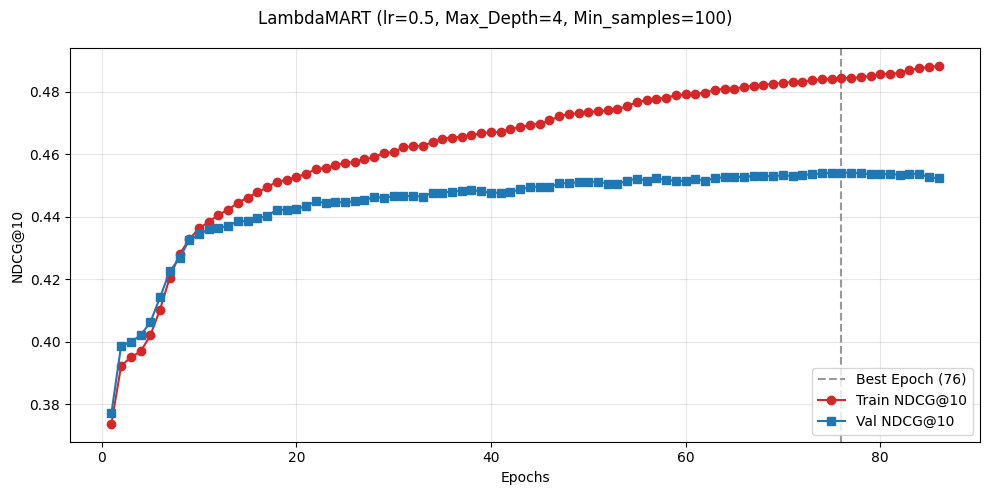

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=4, Min_samples=100)")


## Key Takeaways:
- The model is still overfitting. No need to reduce the `min_samples_leaf`.
- Reducing `Max_depth` is also not good i think as depth=4 is very less.
- We should keep increasing `min_samples_leaf`

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=4, Min_samples=100)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — (lr=0.5, Max_Depth=4, Min_samples=100)
──────────────────────────────
  NDCG@1  : 0.4303
  NDCG@3  : 0.4205
  NDCG@5  : 0.4254
  NDCG@10 : 0.4418


## Key Takeaways:
- As we reduce the `Max_depth` the result is getting better. So, reducing max_depth helping to regularize the model.

# Important Findings:
- Current `min_samples_leaf = 100`, there are 120*6000 = 720000 documents.
- Current `max_depth = 4`, Maximum possible leaves = 16. Documents in one leaf = ~45000. Therefore, `min_samples_leaf=100` is not even a good constraint. It will just split even though a node have some 1000 documents. This is not good.

## Next Steps:
- Use very large `min_samples_leaf` value and since there are large number of documents i will try increasing max_depth and find the best pair of `max_depth` and `min_samples_leaf` to find the best tree complexity.
- Then optimize Learning rate.

## Max_depth = 6, Min_samples_leaf = 2500

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=2500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3935 | Val NDCG@10: 0.3977  <- best
Tree 002 | α*: 0.2703 | η·α*: 0.1351 | Train NDCG@10: 0.4052 | Val NDCG@10: 0.4093  <- best
Tree 003 | α*: 0.5367 | η·α*: 0.2683 | Train NDCG@10: 0.4120 | Val NDCG@10: 0.4157  <- best
Tree 004 | α*: 0.6725 | η·α*: 0.3363 | Train NDCG@10: 0.4207 | Val NDCG@10: 0.4224  <- best
Tree 005 | α*: 0.7474 | η·α*: 0.3737 | Train NDCG@10: 0.4277 | Val NDCG@10: 0.4304  <- best
Tree 006 | α*: 0.9718 | η·α*: 0.4859 | Train NDCG@10: 0.4351 | Val NDCG@10: 0.4366  <- best
Tree 007 | α*: 0.7270 | η·α*: 0.3635 | Train NDCG@10: 0.4400 | Val NDCG@10: 0.4402  <- best
Tree 008 | α*: 0.8526 | η·α*: 0.4263 | Train NDCG@10: 0.4444 | Val NDCG@10: 0.4417  <- best
Tree 009 | α*: 0.7930 | η·α*: 0.3965 | Train NDCG@10: 0.4480 | Val NDCG@10: 0.4439  <- best
Tree 010 | α*: 0.8060 | η·α*: 0.4030 | Train NDCG@10: 0.4519 | Val NDCG@10: 0.4457  <- best
Tree 011 | α*: 0.9094 | η·α*: 0.4547 | Train NDCG@10: 0.4545 | Val NDCG@10: 0.44

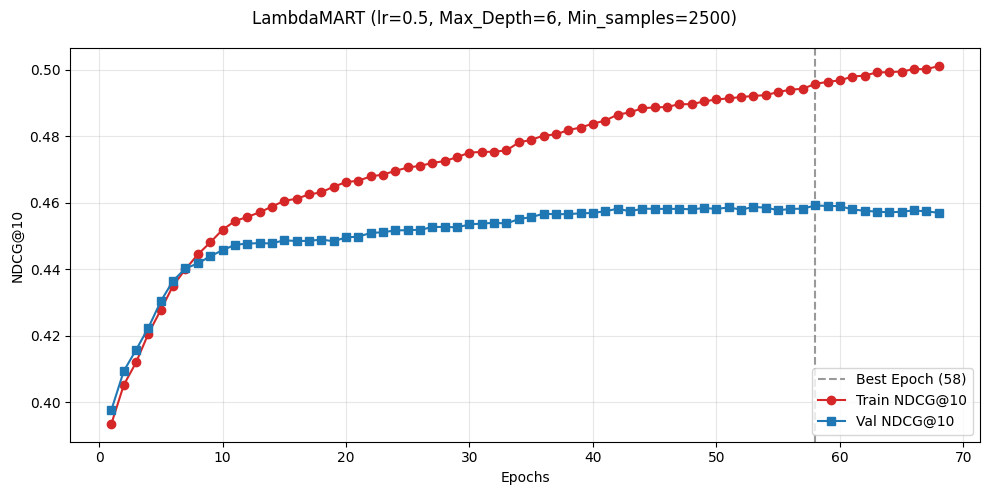

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=6, Min_samples=2500)")

## Key Takeaways:
- The model performed so better than the previous ones. But the overfitting problem still persists. So, I will increase the `min_samples_leaf` furhter.

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=2500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=2500)
──────────────────────────────
  NDCG@1  : 0.4332
  NDCG@3  : 0.4296
  NDCG@5  : 0.4326
  NDCG@10 : 0.4470


## Key Takeaways:
- The Result is close the intial ones and a bit better. If I control ovefitting I can get better results.

## Step 8 · Training (with first 1500 queries only from Fold 1)

Since it is taking very long to train just one model, it became very difficult to perform the Hyperparameter tuning. So, I will use 1500 queries to train and 500 queries for validation and testing to preserve ratio (3:1:1).

In [ ]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH,
    fold_num=1,
    batch_size=4,
    num_train_queries=1500,
    num_val_queries=500,
    num_test_queries=500
)

  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 1501 train | 501 val | 501 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score


# Learning Rate fixed at 0.5

Since 3D grid search takes more time, I will first find the optimal tree complexity by changing max_depth and min_samples_leaf, then optimize the learning rate.

## max_depth = 6, min_samples_leaf = 1000

Total Documents = ~1500*120 =  ~1,80,000    
Max number of leaf nodes = 2^6 = 64   
Number of documents in leaf nodes = 1,80,000/64  =  ~2813

So, I choose 1000 for min_samples_leaf. which is neither higher nor lower.

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=1000,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3810 | Val NDCG@10: 0.3932  <- best
Tree 002 | α*: 0.9750 | η·α*: 0.4875 | Train NDCG@10: 0.4129 | Val NDCG@10: 0.4263  <- best
Tree 003 | α*: 0.6070 | η·α*: 0.3035 | Train NDCG@10: 0.4275 | Val NDCG@10: 0.4411  <- best
Tree 004 | α*: 0.6690 | η·α*: 0.3345 | Train NDCG@10: 0.4379 | Val NDCG@10: 0.4499  <- best
Tree 005 | α*: 0.4853 | η·α*: 0.2427 | Train NDCG@10: 0.4421 | Val NDCG@10: 0.4541  <- best
Tree 006 | α*: 0.8635 | η·α*: 0.4317 | Train NDCG@10: 0.4484 | Val NDCG@10: 0.4509
Tree 007 | α*: 0.7922 | η·α*: 0.3961 | Train NDCG@10: 0.4532 | Val NDCG@10: 0.4542  <- best
Tree 008 | α*: 0.6928 | η·α*: 0.3464 | Train NDCG@10: 0.4558 | Val NDCG@10: 0.4560  <- best
Tree 009 | α*: 0.6284 | η·α*: 0.3142 | Train NDCG@10: 0.4603 | Val NDCG@10: 0.4606  <- best
Tree 010 | α*: 0.6706 | η·α*: 0.3353 | Train NDCG@10: 0.4636 | Val NDCG@10: 0.4611  <- best
Tree 011 | α*: 0.6124 | η·α*: 0.3062 | Train NDCG@10: 0.4673 | Val NDCG@10: 0.4621  <- be

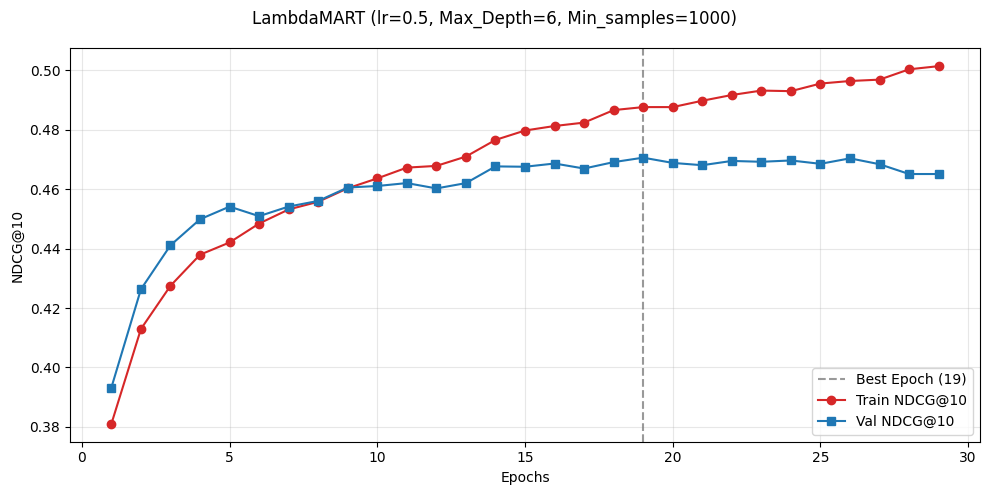

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=6, Min_samples=1000)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=1000)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=1000)
──────────────────────────────
  NDCG@1  : 0.4518
  NDCG@3  : 0.4342
  NDCG@5  : 0.4397
  NDCG@10 : 0.4578


## Key Takeaways:
- The curves look very good, Validation curve went up along with the training curve except the end with a slight gap.
- We got best Val NDCG@10 - **0.470**. This is the highest we got till now.
- The evaluation on test data showed a NDCG@10 of **0.458**. This also the highest test result we got till now.

## Next Steps:
- I want to see if we can further generalize it, so I will increase the min_samples_leaf a little bit.

## max_depth = 6, min_samples_leaf = 1200

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=1200,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3765 | Val NDCG@10: 0.3913  <- best
Tree 002 | α*: 1.1697 | η·α*: 0.5849 | Train NDCG@10: 0.4109 | Val NDCG@10: 0.4236  <- best
Tree 003 | α*: 0.7820 | η·α*: 0.3910 | Train NDCG@10: 0.4275 | Val NDCG@10: 0.4360  <- best
Tree 004 | α*: 0.6240 | η·α*: 0.3120 | Train NDCG@10: 0.4382 | Val NDCG@10: 0.4457  <- best
Tree 005 | α*: 0.6726 | η·α*: 0.3363 | Train NDCG@10: 0.4429 | Val NDCG@10: 0.4518  <- best
Tree 006 | α*: 0.7760 | η·α*: 0.3880 | Train NDCG@10: 0.4471 | Val NDCG@10: 0.4555  <- best
Tree 007 | α*: 1.1185 | η·α*: 0.5592 | Train NDCG@10: 0.4508 | Val NDCG@10: 0.4568  <- best
Tree 008 | α*: 1.0200 | η·α*: 0.5100 | Train NDCG@10: 0.4608 | Val NDCG@10: 0.4627  <- best
Tree 009 | α*: 0.7421 | η·α*: 0.3710 | Train NDCG@10: 0.4627 | Val NDCG@10: 0.4636  <- best
Tree 010 | α*: 0.8673 | η·α*: 0.4336 | Train NDCG@10: 0.4664 | Val NDCG@10: 0.4641  <- best
Tree 011 | α*: 0.8123 | η·α*: 0.4062 | Train NDCG@10: 0.4696 | Val NDCG@10: 0.46

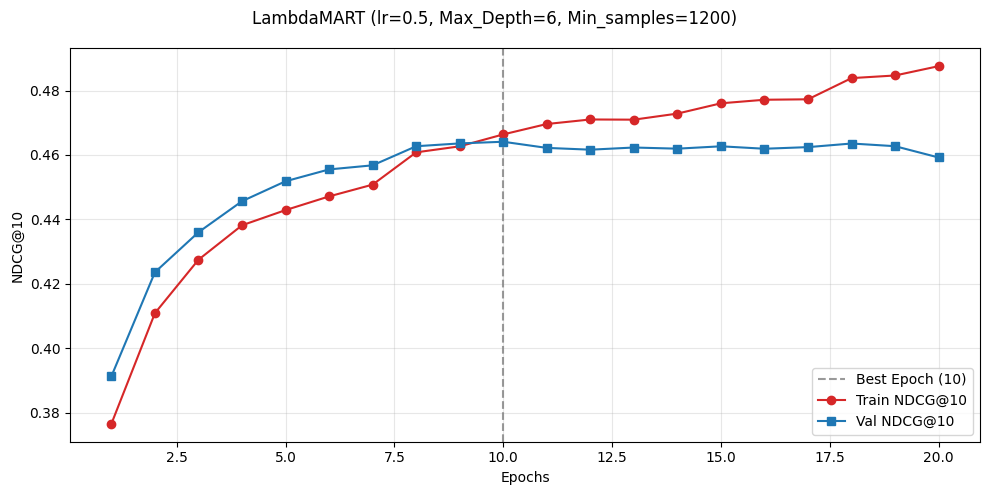

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=6, Min_samples=1200)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=1200)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=1200)
──────────────────────────────
  NDCG@1  : 0.4492
  NDCG@3  : 0.4332
  NDCG@5  : 0.4381
  NDCG@10 : 0.4547


- It didn't perform better than `1000`, Let us check if reducing min_samples_leaf helps us.

## max_depth = 6, min_samples_leaf = 800

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=800,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.4003 | Val NDCG@10: 0.4131  <- best
Tree 002 | α*: 0.2713 | η·α*: 0.1356 | Train NDCG@10: 0.4144 | Val NDCG@10: 0.4261  <- best
Tree 003 | α*: 0.3386 | η·α*: 0.1693 | Train NDCG@10: 0.4207 | Val NDCG@10: 0.4397  <- best
Tree 004 | α*: 0.5187 | η·α*: 0.2594 | Train NDCG@10: 0.4254 | Val NDCG@10: 0.4444  <- best
Tree 005 | α*: 0.6301 | η·α*: 0.3150 | Train NDCG@10: 0.4350 | Val NDCG@10: 0.4537  <- best
Tree 006 | α*: 0.6381 | η·α*: 0.3191 | Train NDCG@10: 0.4430 | Val NDCG@10: 0.4603  <- best
Tree 007 | α*: 0.6961 | η·α*: 0.3480 | Train NDCG@10: 0.4519 | Val NDCG@10: 0.4613  <- best
Tree 008 | α*: 0.6794 | η·α*: 0.3397 | Train NDCG@10: 0.4573 | Val NDCG@10: 0.4631  <- best
Tree 009 | α*: 0.7865 | η·α*: 0.3933 | Train NDCG@10: 0.4622 | Val NDCG@10: 0.4695  <- best
Tree 010 | α*: 0.7114 | η·α*: 0.3557 | Train NDCG@10: 0.4666 | Val NDCG@10: 0.4689
Tree 011 | α*: 0.8395 | η·α*: 0.4197 | Train NDCG@10: 0.4727 | Val NDCG@10: 0.4699  <- be

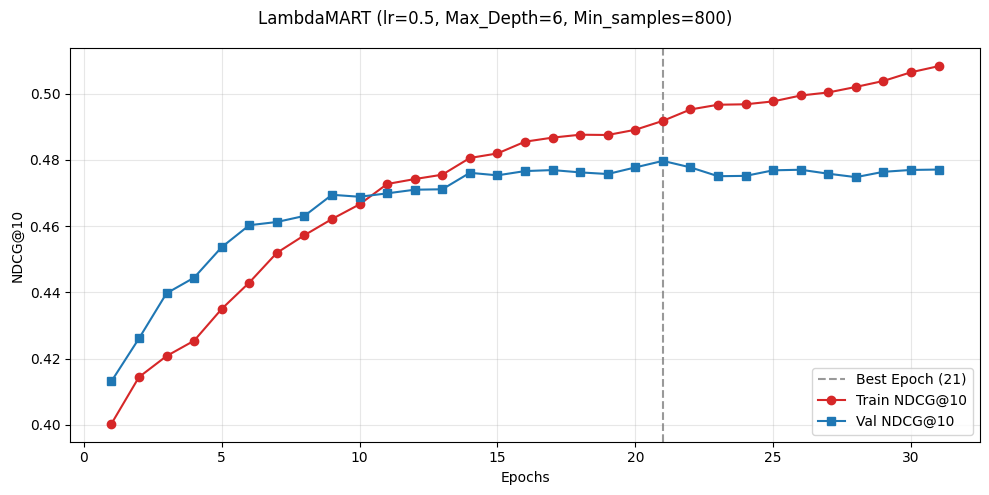

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=6, Min_samples=800)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=800)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=800)
──────────────────────────────
  NDCG@1  : 0.4518
  NDCG@3  : 0.4382
  NDCG@5  : 0.4415
  NDCG@10 : 0.4602


- This performed better than `1000`, Let us see if reducing `min_samples_leaf` further will help.

## max_depth = 6, min_samples_leaf = 600

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=600,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.4014 | Val NDCG@10: 0.4159  <- best
Tree 002 | α*: 0.3370 | η·α*: 0.1685 | Train NDCG@10: 0.4177 | Val NDCG@10: 0.4316  <- best
Tree 003 | α*: 0.6681 | η·α*: 0.3340 | Train NDCG@10: 0.4250 | Val NDCG@10: 0.4360  <- best
Tree 004 | α*: 0.7548 | η·α*: 0.3774 | Train NDCG@10: 0.4334 | Val NDCG@10: 0.4470  <- best
Tree 005 | α*: 0.7850 | η·α*: 0.3925 | Train NDCG@10: 0.4408 | Val NDCG@10: 0.4529  <- best
Tree 006 | α*: 0.8518 | η·α*: 0.4259 | Train NDCG@10: 0.4517 | Val NDCG@10: 0.4623  <- best
Tree 007 | α*: 0.5383 | η·α*: 0.2692 | Train NDCG@10: 0.4542 | Val NDCG@10: 0.4629  <- best
Tree 008 | α*: 0.7144 | η·α*: 0.3572 | Train NDCG@10: 0.4594 | Val NDCG@10: 0.4649  <- best
Tree 009 | α*: 0.7408 | η·α*: 0.3704 | Train NDCG@10: 0.4637 | Val NDCG@10: 0.4683  <- best
Tree 010 | α*: 1.0225 | η·α*: 0.5112 | Train NDCG@10: 0.4694 | Val NDCG@10: 0.4664
Tree 011 | α*: 0.6596 | η·α*: 0.3298 | Train NDCG@10: 0.4722 | Val NDCG@10: 0.4652
Tree 0

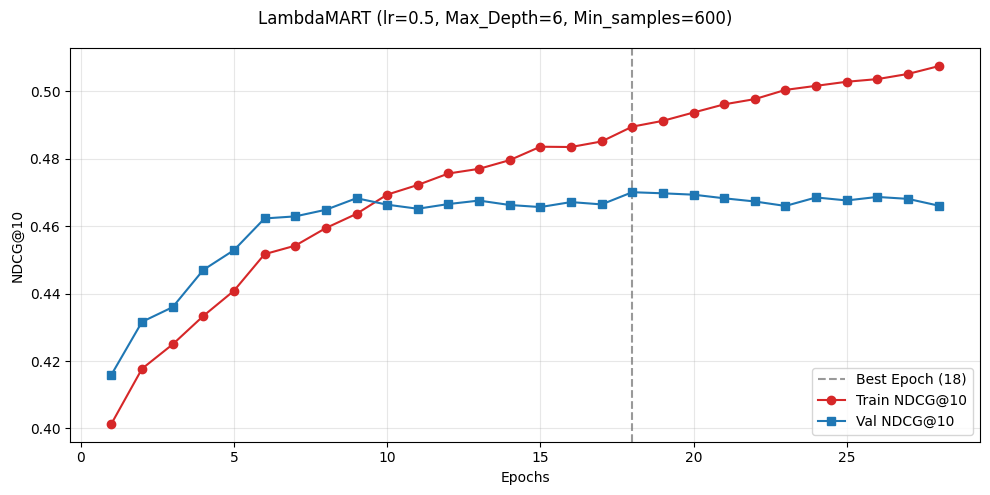

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=6, Min_samples=600)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=600)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=600)
──────────────────────────────
  NDCG@1  : 0.4373
  NDCG@3  : 0.4237
  NDCG@5  : 0.4353
  NDCG@10 : 0.4520


- It didn't perform well, So, for `max_depth=6` the optimal cofiguration is `min_samples_leaf=800`.
- Let us try changing max_depth.

## max_depth = 5, min_samples_leaf = 2000

Since, reducing `max_depth` by **1** reduce the max number of leaves to half. So, I prefer choosing `min_samples_leaf=2000` which is double of the base we used in `max_depth=6`.

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=5,
    min_samples_leaf=2000,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3697 | Val NDCG@10: 0.3932  <- best
Tree 002 | α*: 0.5717 | η·α*: 0.2859 | Train NDCG@10: 0.3839 | Val NDCG@10: 0.4101  <- best
Tree 003 | α*: 17.5470 | η·α*: 8.7735 | Train NDCG@10: 0.3900 | Val NDCG@10: 0.4196  <- best
Tree 004 | α*: 0.0031 | η·α*: 0.0016 | Train NDCG@10: 0.3896 | Val NDCG@10: 0.4190
Tree 005 | α*: 0.0002 | η·α*: 0.0001 | Train NDCG@10: 0.3897 | Val NDCG@10: 0.4191
Tree 006 | α*: 0.0001 | η·α*: 0.0001 | Train NDCG@10: 0.3899 | Val NDCG@10: 0.4192
Tree 007 | α*: 0.0006 | η·α*: 0.0003 | Train NDCG@10: 0.3907 | Val NDCG@10: 0.4193
Tree 008 | α*: 0.0005 | η·α*: 0.0002 | Train NDCG@10: 0.3906 | Val NDCG@10: 0.4192
Tree 009 | α*: 0.0002 | η·α*: 0.0001 | Train NDCG@10: 0.3906 | Val NDCG@10: 0.4192
Tree 010 | α*: 0.0001 | η·α*: 0.0001 | Train NDCG@10: 0.3906 | Val NDCG@10: 0.4192
Tree 011 | α*: 0.0003 | η·α*: 0.0001 | Train NDCG@10: 0.3905 | Val NDCG@10: 0.4191
Tree 012 | α*: 0.0001 | η·α*: 0.0001 | Train NDCG@10: 0.390

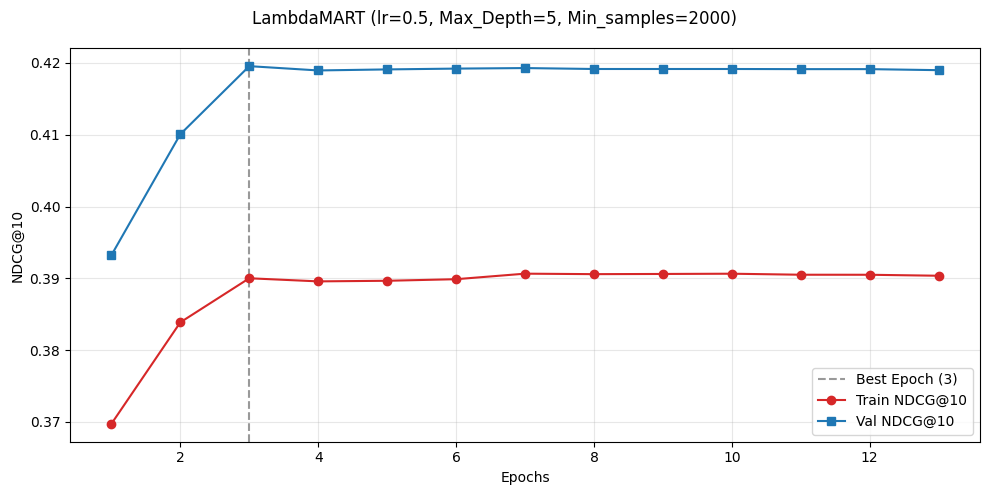

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=5, Min_samples=2000)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=2000)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=2000)
──────────────────────────────
  NDCG@1  : 0.3563
  NDCG@3  : 0.3802
  NDCG@5  : 0.3830
  NDCG@10 : 0.4018


- It seems the model is severly underfitted, Reduce `min_samples_leaf` will increase tree complexity and help in solve overfitting.

## max_depth = 5, min_samples_leaf = 1000

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=5,
    min_samples_leaf=1000,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3773 | Val NDCG@10: 0.3998  <- best
Tree 002 | α*: 3.6236 | η·α*: 1.8118 | Train NDCG@10: 0.4014 | Val NDCG@10: 0.4246  <- best
Tree 003 | α*: 0.2105 | η·α*: 0.1052 | Train NDCG@10: 0.4022 | Val NDCG@10: 0.4230
Tree 004 | α*: 0.3437 | η·α*: 0.1719 | Train NDCG@10: 0.4050 | Val NDCG@10: 0.4214
Tree 005 | α*: 0.5450 | η·α*: 0.2725 | Train NDCG@10: 0.4082 | Val NDCG@10: 0.4241
Tree 006 | α*: 0.8549 | η·α*: 0.4275 | Train NDCG@10: 0.4158 | Val NDCG@10: 0.4268  <- best
Tree 007 | α*: 0.8200 | η·α*: 0.4100 | Train NDCG@10: 0.4287 | Val NDCG@10: 0.4306  <- best
Tree 008 | α*: 0.8380 | η·α*: 0.4190 | Train NDCG@10: 0.4356 | Val NDCG@10: 0.4391  <- best
Tree 009 | α*: 0.9099 | η·α*: 0.4549 | Train NDCG@10: 0.4393 | Val NDCG@10: 0.4408  <- best
Tree 010 | α*: 1.5272 | η·α*: 0.7636 | Train NDCG@10: 0.4477 | Val NDCG@10: 0.4436  <- best
Tree 011 | α*: 0.5092 | η·α*: 0.2546 | Train NDCG@10: 0.4502 | Val NDCG@10: 0.4465  <- best
Tree 012 | α*: 

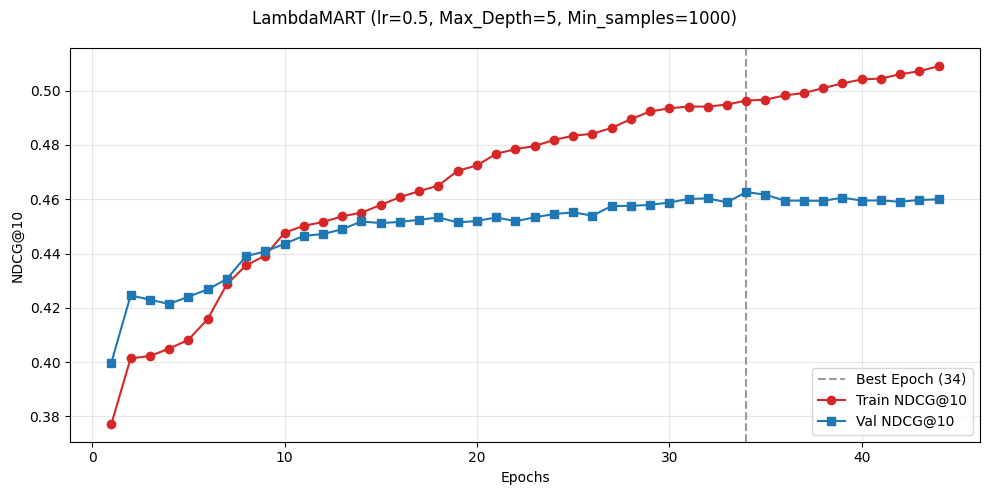

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=5, Min_samples=1000)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=1000)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=1000)
──────────────────────────────
  NDCG@1  : 0.4429
  NDCG@3  : 0.4381
  NDCG@5  : 0.4429
  NDCG@10 : 0.4588


- As expected, The underfitting problem is solved and we got a good result, but we can see a gap between train and val curves which is a sign of overfitting.
- let us increase `min_samples_leaf` a bit to handle overfitting.

## max_depth = 5, min_samples_leaf = 1500

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=5,
    min_samples_leaf=1500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3736 | Val NDCG@10: 0.3947  <- best
Tree 002 | α*: 1.4561 | η·α*: 0.7281 | Train NDCG@10: 0.3985 | Val NDCG@10: 0.4198  <- best
Tree 003 | α*: 0.9807 | η·α*: 0.4904 | Train NDCG@10: 0.4191 | Val NDCG@10: 0.4345  <- best
Tree 004 | α*: 1.0090 | η·α*: 0.5045 | Train NDCG@10: 0.4274 | Val NDCG@10: 0.4399  <- best
Tree 005 | α*: 1.0128 | η·α*: 0.5064 | Train NDCG@10: 0.4328 | Val NDCG@10: 0.4428  <- best
Tree 006 | α*: 0.7145 | η·α*: 0.3572 | Train NDCG@10: 0.4369 | Val NDCG@10: 0.4435  <- best
Tree 007 | α*: 1.2177 | η·α*: 0.6089 | Train NDCG@10: 0.4445 | Val NDCG@10: 0.4482  <- best
Tree 008 | α*: 0.6970 | η·α*: 0.3485 | Train NDCG@10: 0.4488 | Val NDCG@10: 0.4459
Tree 009 | α*: 0.9440 | η·α*: 0.4720 | Train NDCG@10: 0.4523 | Val NDCG@10: 0.4490  <- best
Tree 010 | α*: 0.9444 | η·α*: 0.4722 | Train NDCG@10: 0.4548 | Val NDCG@10: 0.4517  <- best
Tree 011 | α*: 0.9871 | η·α*: 0.4936 | Train NDCG@10: 0.4553 | Val NDCG@10: 0.4487
Tree 0

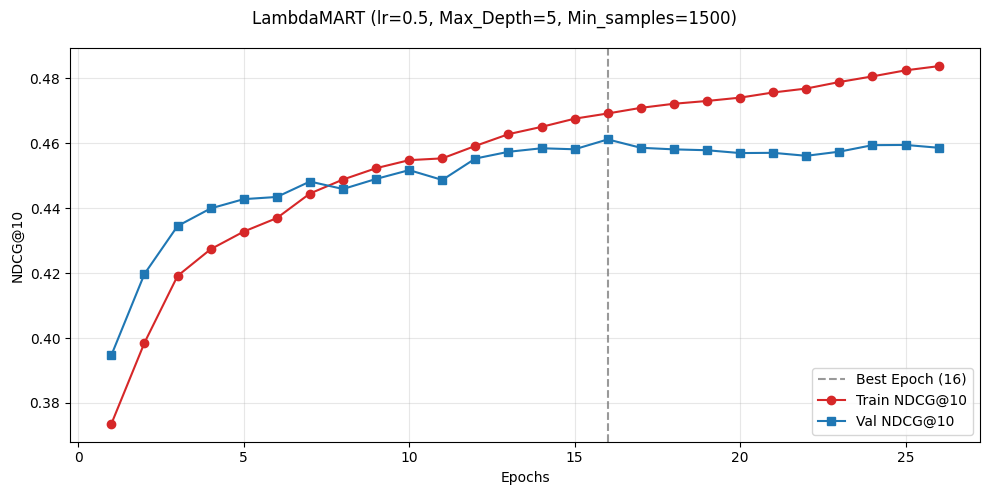

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=5, Min_samples=1500)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=1500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=1500)
──────────────────────────────
  NDCG@1  : 0.4448
  NDCG@3  : 0.4343
  NDCG@5  : 0.4398
  NDCG@10 : 0.4543


- The gap closed but the result is a little bit less.
- Since, Training curve is going upto **0.48**, let us see if we can make the curves further close by increasing `min_samples_leaf`.

## max_depth = 5, min_samples_leaf = 1700

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=5,
    min_samples_leaf=1700,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3693 | Val NDCG@10: 0.3928  <- best
Tree 002 | α*: 0.8030 | η·α*: 0.4015 | Train NDCG@10: 0.3941 | Val NDCG@10: 0.4155  <- best
Tree 003 | α*: 1.1709 | η·α*: 0.5854 | Train NDCG@10: 0.4085 | Val NDCG@10: 0.4379  <- best
Tree 004 | α*: 0.9238 | η·α*: 0.4619 | Train NDCG@10: 0.4253 | Val NDCG@10: 0.4531  <- best
Tree 005 | α*: 0.9957 | η·α*: 0.4979 | Train NDCG@10: 0.4347 | Val NDCG@10: 0.4560  <- best
Tree 006 | α*: 0.7063 | η·α*: 0.3531 | Train NDCG@10: 0.4402 | Val NDCG@10: 0.4580  <- best
Tree 007 | α*: 0.9304 | η·α*: 0.4652 | Train NDCG@10: 0.4462 | Val NDCG@10: 0.4623  <- best
Tree 008 | α*: 0.7966 | η·α*: 0.3983 | Train NDCG@10: 0.4460 | Val NDCG@10: 0.4641  <- best
Tree 009 | α*: 0.9751 | η·α*: 0.4875 | Train NDCG@10: 0.4522 | Val NDCG@10: 0.4680  <- best
Tree 010 | α*: 1.1010 | η·α*: 0.5505 | Train NDCG@10: 0.4574 | Val NDCG@10: 0.4680  <- best
Tree 011 | α*: 1.2145 | η·α*: 0.6073 | Train NDCG@10: 0.4597 | Val NDCG@10: 0.46

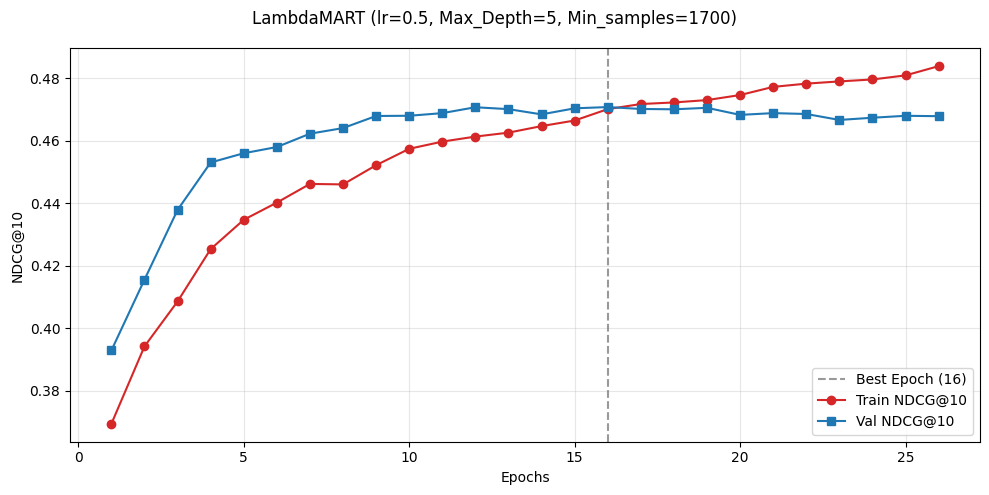

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=5, Min_samples=1700)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=1700)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=1700)
──────────────────────────────
  NDCG@1  : 0.4210
  NDCG@3  : 0.4245
  NDCG@5  : 0.4330
  NDCG@10 : 0.4505


- The result is poor.
- The best cofiguration for `max_depth=5` is `min_samples_leaf=1000` i.e, **0.4505**. This is still less than the best of `max_depth=6` which is **0.4602**.
- Decreasing `max_depth` doesn't help. Let us try increasing it.

## max_depth = 7, min_samples_leaf = 500

- For `max_depth=6`, we used `min_samples_leaf=1000` as a base.
- Now for `max_depth=7`, The maximum number of leaves is doubled. So, let us consider `min_samples_leaf=500` as a base.

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=7,
    min_samples_leaf=500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.4051 | Val NDCG@10: 0.4197  <- best
Tree 002 | α*: 0.3771 | η·α*: 0.1885 | Train NDCG@10: 0.4285 | Val NDCG@10: 0.4418  <- best
Tree 003 | α*: 0.2287 | η·α*: 0.1143 | Train NDCG@10: 0.4357 | Val NDCG@10: 0.4449  <- best
Tree 004 | α*: 0.3674 | η·α*: 0.1837 | Train NDCG@10: 0.4416 | Val NDCG@10: 0.4489  <- best
Tree 005 | α*: 0.3319 | η·α*: 0.1660 | Train NDCG@10: 0.4437 | Val NDCG@10: 0.4548  <- best
Tree 006 | α*: 0.5699 | η·α*: 0.2850 | Train NDCG@10: 0.4476 | Val NDCG@10: 0.4567  <- best
Tree 007 | α*: 0.6740 | η·α*: 0.3370 | Train NDCG@10: 0.4571 | Val NDCG@10: 0.4623  <- best
Tree 008 | α*: 0.5275 | η·α*: 0.2638 | Train NDCG@10: 0.4630 | Val NDCG@10: 0.4667  <- best
Tree 009 | α*: 0.8098 | η·α*: 0.4049 | Train NDCG@10: 0.4691 | Val NDCG@10: 0.4691  <- best
Tree 010 | α*: 0.6366 | η·α*: 0.3183 | Train NDCG@10: 0.4744 | Val NDCG@10: 0.4709  <- best
Tree 011 | α*: 0.8793 | η·α*: 0.4396 | Train NDCG@10: 0.4807 | Val NDCG@10: 0.47

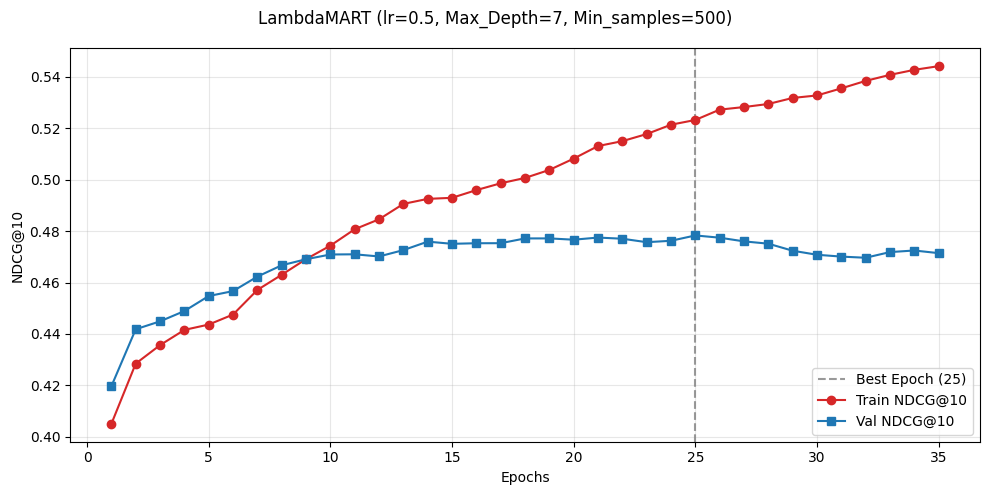

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=7, Min_samples=500)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=500)
──────────────────────────────
  NDCG@1  : 0.4489
  NDCG@3  : 0.4391
  NDCG@5  : 0.4433
  NDCG@10 : 0.4640


- This is the best result we got so far. But the curves show signs of overfitting.
- Let us increase `min_samples_leaf` to handle overfitting.

## max_depth = 7, min_samples_leaf = 800

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=7,
    min_samples_leaf=800,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.4070 | Val NDCG@10: 0.4145  <- best
Tree 002 | α*: 0.2440 | η·α*: 0.1220 | Train NDCG@10: 0.4192 | Val NDCG@10: 0.4291  <- best
Tree 003 | α*: 0.5663 | η·α*: 0.2832 | Train NDCG@10: 0.4257 | Val NDCG@10: 0.4398  <- best
Tree 004 | α*: 0.4524 | η·α*: 0.2262 | Train NDCG@10: 0.4323 | Val NDCG@10: 0.4507  <- best
Tree 005 | α*: 0.6231 | η·α*: 0.3115 | Train NDCG@10: 0.4400 | Val NDCG@10: 0.4548  <- best
Tree 006 | α*: 0.5838 | η·α*: 0.2919 | Train NDCG@10: 0.4491 | Val NDCG@10: 0.4625  <- best
Tree 007 | α*: 0.5841 | η·α*: 0.2921 | Train NDCG@10: 0.4578 | Val NDCG@10: 0.4633  <- best
Tree 008 | α*: 0.4951 | η·α*: 0.2475 | Train NDCG@10: 0.4620 | Val NDCG@10: 0.4667  <- best
Tree 009 | α*: 0.5246 | η·α*: 0.2623 | Train NDCG@10: 0.4686 | Val NDCG@10: 0.4694  <- best
Tree 010 | α*: 0.3786 | η·α*: 0.1893 | Train NDCG@10: 0.4709 | Val NDCG@10: 0.4683
Tree 011 | α*: 0.7060 | η·α*: 0.3530 | Train NDCG@10: 0.4762 | Val NDCG@10: 0.4681
Tree 0

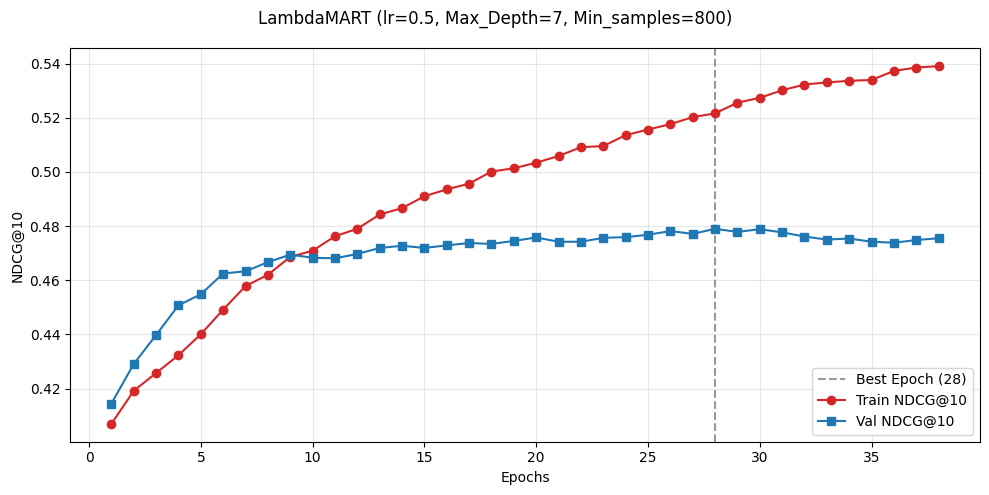

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=7, Min_samples=800)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=800)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=800)
──────────────────────────────
  NDCG@1  : 0.4287
  NDCG@3  : 0.4330
  NDCG@5  : 0.4437
  NDCG@10 : 0.4585


- The best **Val NDCG** is improved (0.4783->0.4790), But the result is a bit reduced, this might be a noise.
- Let us increase the `min_samples_leaf` to verify if increasing it doesn't help.

## max_depth = 7, min_samples_leaf = 1000

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=7,
    min_samples_leaf=1000,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3881 | Val NDCG@10: 0.3957  <- best
Tree 002 | α*: 1.6937 | η·α*: 0.8468 | Train NDCG@10: 0.4155 | Val NDCG@10: 0.4313  <- best
Tree 003 | α*: 0.6527 | η·α*: 0.3264 | Train NDCG@10: 0.4272 | Val NDCG@10: 0.4385  <- best
Tree 004 | α*: 0.7744 | η·α*: 0.3872 | Train NDCG@10: 0.4377 | Val NDCG@10: 0.4413  <- best
Tree 005 | α*: 0.8149 | η·α*: 0.4075 | Train NDCG@10: 0.4453 | Val NDCG@10: 0.4493  <- best
Tree 006 | α*: 0.9541 | η·α*: 0.4771 | Train NDCG@10: 0.4555 | Val NDCG@10: 0.4536  <- best
Tree 007 | α*: 0.7552 | η·α*: 0.3776 | Train NDCG@10: 0.4633 | Val NDCG@10: 0.4568  <- best
Tree 008 | α*: 0.7090 | η·α*: 0.3545 | Train NDCG@10: 0.4664 | Val NDCG@10: 0.4556
Tree 009 | α*: 0.6322 | η·α*: 0.3161 | Train NDCG@10: 0.4683 | Val NDCG@10: 0.4549
Tree 010 | α*: 0.7923 | η·α*: 0.3962 | Train NDCG@10: 0.4719 | Val NDCG@10: 0.4572  <- best
Tree 011 | α*: 0.8958 | η·α*: 0.4479 | Train NDCG@10: 0.4756 | Val NDCG@10: 0.4553
Tree 012 | α*: 

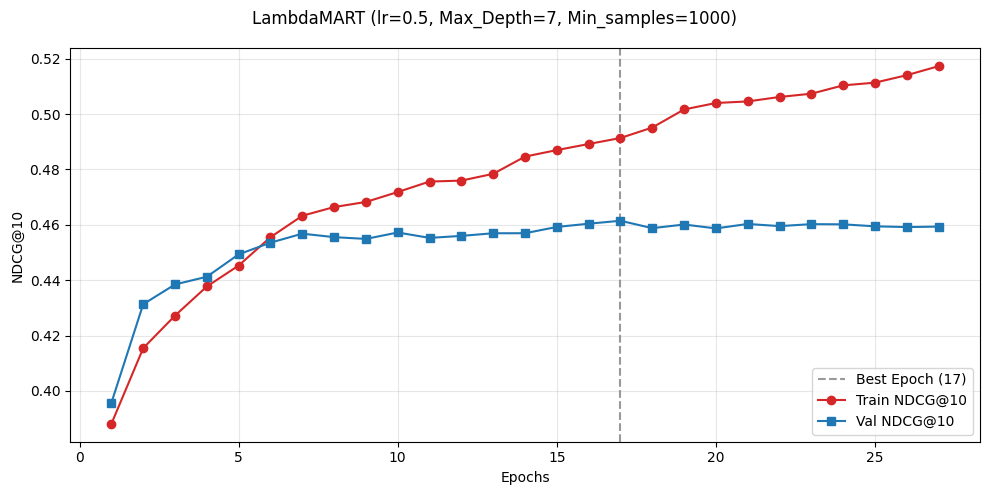

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=7, Min_samples=1000)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=1000)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=1000)
──────────────────────────────
  NDCG@1  : 0.4414
  NDCG@3  : 0.4292
  NDCG@5  : 0.4325
  NDCG@10 : 0.4526


- The result is poor. So, we can say that increasing `min_samples_leaf` doesn't help, the overfitting here is either because of `max_depth` or `learning_rate`.
- The best configuration for `max_dapth=7` is `min_samples_leaf=500`.
- Best result till now is `max_depth=7, min_samples_leaf=500` = **0.4640**. We got better result by increasing `max_depth`.
- Let us try increasing `max_depth` further.

## max_depth = 8, min_samples_leaf = 250

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=8,
    min_samples_leaf=250,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.4135 | Val NDCG@10: 0.4116  <- best
Tree 002 | α*: 0.2274 | η·α*: 0.1137 | Train NDCG@10: 0.4398 | Val NDCG@10: 0.4298  <- best
Tree 003 | α*: 0.2450 | η·α*: 0.1225 | Train NDCG@10: 0.4501 | Val NDCG@10: 0.4380  <- best
Tree 004 | α*: 0.3091 | η·α*: 0.1545 | Train NDCG@10: 0.4574 | Val NDCG@10: 0.4447  <- best
Tree 005 | α*: 0.2997 | η·α*: 0.1499 | Train NDCG@10: 0.4619 | Val NDCG@10: 0.4521  <- best
Tree 006 | α*: 0.2799 | η·α*: 0.1399 | Train NDCG@10: 0.4665 | Val NDCG@10: 0.4563  <- best
Tree 007 | α*: 0.2822 | η·α*: 0.1411 | Train NDCG@10: 0.4723 | Val NDCG@10: 0.4569  <- best
Tree 008 | α*: 0.4485 | η·α*: 0.2243 | Train NDCG@10: 0.4757 | Val NDCG@10: 0.4591  <- best
Tree 009 | α*: 0.4372 | η·α*: 0.2186 | Train NDCG@10: 0.4832 | Val NDCG@10: 0.4675  <- best
Tree 010 | α*: 0.4663 | η·α*: 0.2331 | Train NDCG@10: 0.4906 | Val NDCG@10: 0.4683  <- best
Tree 011 | α*: 0.8445 | η·α*: 0.4222 | Train NDCG@10: 0.4962 | Val NDCG@10: 0.47

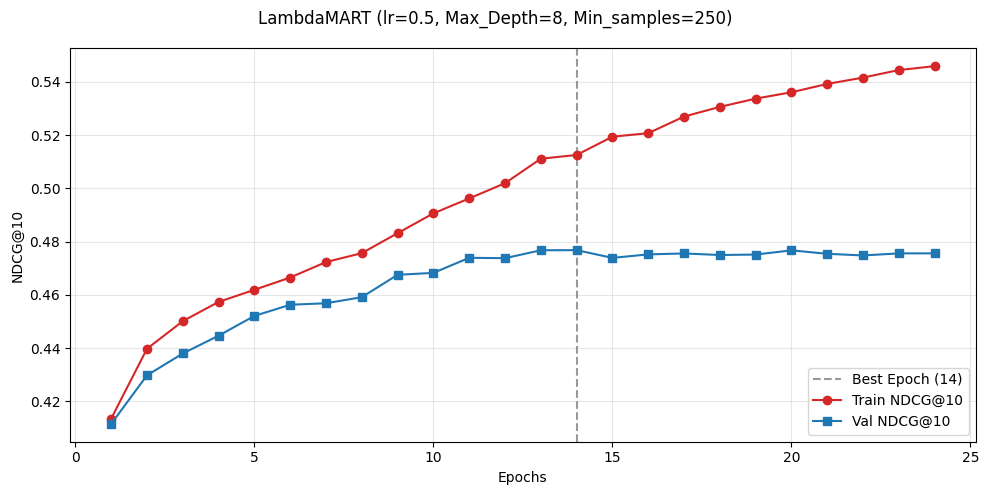

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=8, Min_samples=250)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=8, Min_samples=250)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=8, Min_samples=250)
──────────────────────────────
  NDCG@1  : 0.4422
  NDCG@3  : 0.4291
  NDCG@5  : 0.4434
  NDCG@10 : 0.4600


- The result is close to the best one, Let us see we can handle overfitting here by increasing `min_samples_leaf`.

## max_depth = 8, min_samples_leaf = 500

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=8,
    min_samples_leaf=500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.4100 | Val NDCG@10: 0.4206  <- best
Tree 002 | α*: 0.2133 | η·α*: 0.1067 | Train NDCG@10: 0.4304 | Val NDCG@10: 0.4359  <- best
Tree 003 | α*: 0.4094 | η·α*: 0.2047 | Train NDCG@10: 0.4386 | Val NDCG@10: 0.4448  <- best
Tree 004 | α*: 0.2224 | η·α*: 0.1112 | Train NDCG@10: 0.4454 | Val NDCG@10: 0.4492  <- best
Tree 005 | α*: 0.4646 | η·α*: 0.2323 | Train NDCG@10: 0.4499 | Val NDCG@10: 0.4536  <- best
Tree 006 | α*: 0.5491 | η·α*: 0.2746 | Train NDCG@10: 0.4612 | Val NDCG@10: 0.4580  <- best
Tree 007 | α*: 0.7488 | η·α*: 0.3744 | Train NDCG@10: 0.4676 | Val NDCG@10: 0.4652  <- best
Tree 008 | α*: 0.5343 | η·α*: 0.2672 | Train NDCG@10: 0.4766 | Val NDCG@10: 0.4677  <- best
Tree 009 | α*: 0.7505 | η·α*: 0.3752 | Train NDCG@10: 0.4863 | Val NDCG@10: 0.4720  <- best
Tree 010 | α*: 0.3472 | η·α*: 0.1736 | Train NDCG@10: 0.4880 | Val NDCG@10: 0.4734  <- best
Tree 011 | α*: 0.5344 | η·α*: 0.2672 | Train NDCG@10: 0.4928 | Val NDCG@10: 0.47

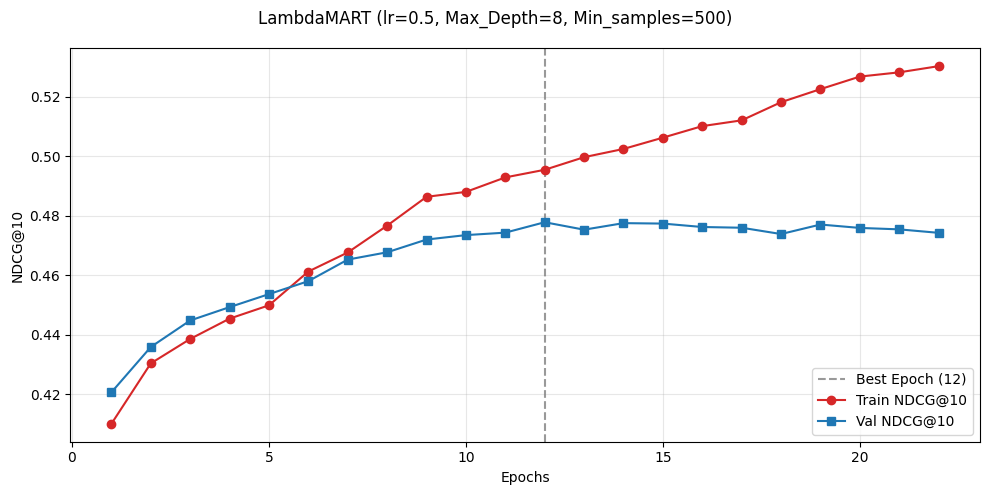

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=8, Min_samples=500)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=8, Min_samples=500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=8, Min_samples=500)
──────────────────────────────
  NDCG@1  : 0.4441
  NDCG@3  : 0.4393
  NDCG@5  : 0.4472
  NDCG@10 : 0.4591


- Again the result is poor but close, let us verify by further increasing the `min_samples_leaf`.

## max_depth = 8, min_samples_leaf = 1000

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=8,
    min_samples_leaf=1000,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3865 | Val NDCG@10: 0.3977  <- best
Tree 002 | α*: 1.8285 | η·α*: 0.9143 | Train NDCG@10: 0.4184 | Val NDCG@10: 0.4347  <- best
Tree 003 | α*: 0.7441 | η·α*: 0.3721 | Train NDCG@10: 0.4329 | Val NDCG@10: 0.4389  <- best
Tree 004 | α*: 0.7264 | η·α*: 0.3632 | Train NDCG@10: 0.4404 | Val NDCG@10: 0.4427  <- best
Tree 005 | α*: 0.7506 | η·α*: 0.3753 | Train NDCG@10: 0.4502 | Val NDCG@10: 0.4467  <- best
Tree 006 | α*: 0.8312 | η·α*: 0.4156 | Train NDCG@10: 0.4572 | Val NDCG@10: 0.4516  <- best
Tree 007 | α*: 0.5988 | η·α*: 0.2994 | Train NDCG@10: 0.4621 | Val NDCG@10: 0.4522  <- best
Tree 008 | α*: 0.8652 | η·α*: 0.4326 | Train NDCG@10: 0.4701 | Val NDCG@10: 0.4538  <- best
Tree 009 | α*: 0.8075 | η·α*: 0.4038 | Train NDCG@10: 0.4736 | Val NDCG@10: 0.4543  <- best
Tree 010 | α*: 0.9598 | η·α*: 0.4799 | Train NDCG@10: 0.4818 | Val NDCG@10: 0.4570  <- best
Tree 011 | α*: 0.8579 | η·α*: 0.4290 | Train NDCG@10: 0.4880 | Val NDCG@10: 0.46

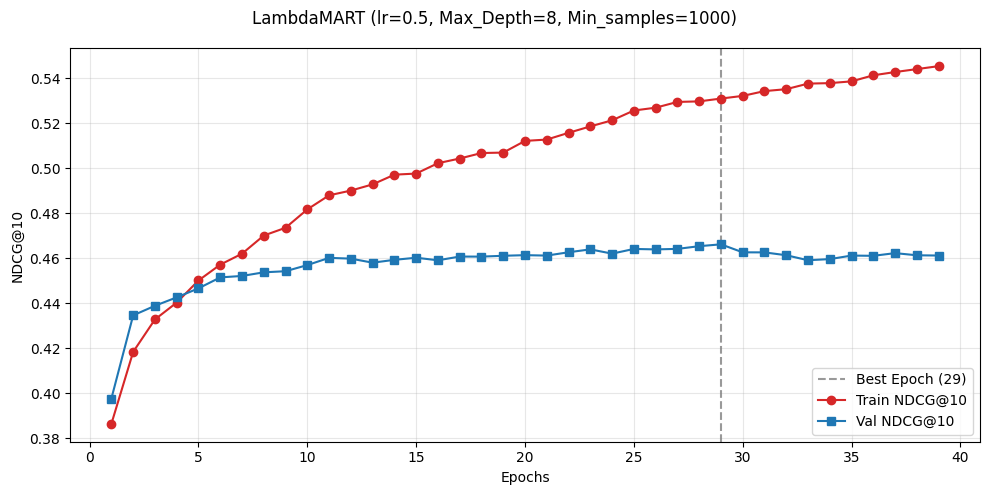

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=8, Min_samples=1000)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=8, Min_samples=1000)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=8, Min_samples=1000)
──────────────────────────────
  NDCG@1  : 0.4148
  NDCG@3  : 0.4231
  NDCG@5  : 0.4317
  NDCG@10 : 0.4479


- The result declined. This says that increasing `min_samples_leaf` doesn't help.
- The best configuration for `max_depth=8` is `min_samples_leaf=250`.
- Best Result for `max_depth=8` = **0.4600**, Best result so far is **0.4640**. The difference is very small. Let us try increasing `max_depth` further.

## max_depth = 9, min_samples_leaf = 150

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=9,
    min_samples_leaf=150,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.4163 | Val NDCG@10: 0.3914  <- best
Tree 002 | α*: 0.3259 | η·α*: 0.1629 | Train NDCG@10: 0.4553 | Val NDCG@10: 0.4364  <- best
Tree 003 | α*: 0.2667 | η·α*: 0.1333 | Train NDCG@10: 0.4695 | Val NDCG@10: 0.4446  <- best
Tree 004 | α*: 0.3866 | η·α*: 0.1933 | Train NDCG@10: 0.4795 | Val NDCG@10: 0.4494  <- best
Tree 005 | α*: 0.2744 | η·α*: 0.1372 | Train NDCG@10: 0.4878 | Val NDCG@10: 0.4543  <- best
Tree 006 | α*: 0.4174 | η·α*: 0.2087 | Train NDCG@10: 0.4923 | Val NDCG@10: 0.4566  <- best
Tree 007 | α*: 0.5174 | η·α*: 0.2587 | Train NDCG@10: 0.5011 | Val NDCG@10: 0.4617  <- best
Tree 008 | α*: 0.4910 | η·α*: 0.2455 | Train NDCG@10: 0.5108 | Val NDCG@10: 0.4619  <- best
Tree 009 | α*: 0.6884 | η·α*: 0.3442 | Train NDCG@10: 0.5171 | Val NDCG@10: 0.4620  <- best
Tree 010 | α*: 0.5995 | η·α*: 0.2998 | Train NDCG@10: 0.5274 | Val NDCG@10: 0.4646  <- best
Tree 011 | α*: 0.5005 | η·α*: 0.2502 | Train NDCG@10: 0.5314 | Val NDCG@10: 0.46

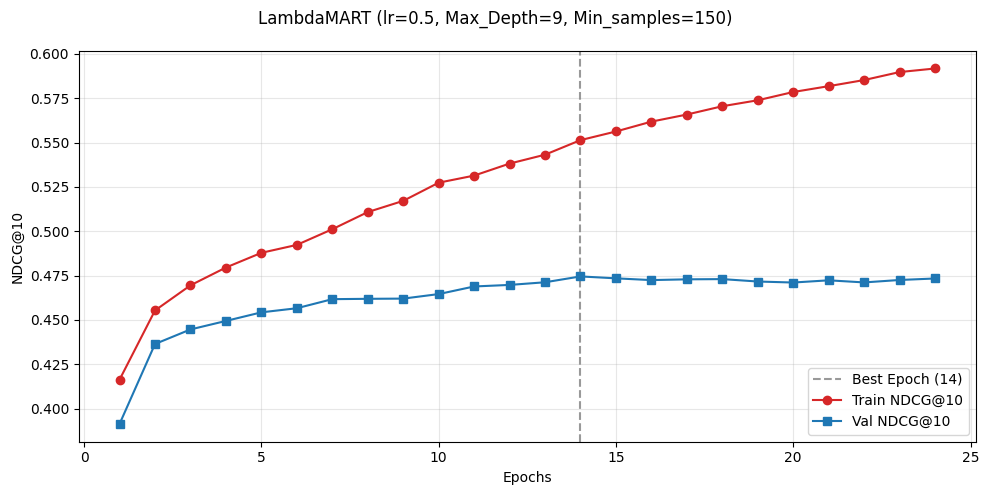

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=9, Min_samples=150)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=9, Min_samples=150)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=9, Min_samples=150)
──────────────────────────────
  NDCG@1  : 0.4422
  NDCG@3  : 0.4296
  NDCG@5  : 0.4336
  NDCG@10 : 0.4542


- The result is poor. So, increasing `max_depth` will not help us anymore.
- The best configuration till now - `max_depth=7, min_samples_leaf=500`.
- Let us fix the Tree complexity and tune `learning rate`.

# max_depth = 7, min_samples_leaf = 500(fixed)

## learning rate = 0.1

- Decreasing learning rate will generalize the model more.
- Very low learning rate might cause **Underfitting** and very high learning rate might cause **Overfitting**.
- At `learning rate=0.5`, we can see it is overfitting. Let us start from **0.1**.

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    min_samples_leaf=500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.1000 | η·α*: 0.0100 | Train NDCG@10: 0.4051 | Val NDCG@10: 0.4197  <- best
Tree 002 | α*: 0.0089 | η·α*: 0.0009 | Train NDCG@10: 0.4168 | Val NDCG@10: 0.4272  <- best
Tree 003 | α*: 0.0087 | η·α*: 0.0009 | Train NDCG@10: 0.4212 | Val NDCG@10: 0.4303  <- best
Tree 004 | α*: 0.0055 | η·α*: 0.0005 | Train NDCG@10: 0.4222 | Val NDCG@10: 0.4296
Tree 005 | α*: 0.0099 | η·α*: 0.0010 | Train NDCG@10: 0.4241 | Val NDCG@10: 0.4315  <- best
Tree 006 | α*: 0.0043 | η·α*: 0.0004 | Train NDCG@10: 0.4251 | Val NDCG@10: 0.4322  <- best
Tree 007 | α*: 0.0079 | η·α*: 0.0008 | Train NDCG@10: 0.4259 | Val NDCG@10: 0.4320
Tree 008 | α*: 0.0083 | η·α*: 0.0008 | Train NDCG@10: 0.4258 | Val NDCG@10: 0.4331  <- best
Tree 009 | α*: 0.0082 | η·α*: 0.0008 | Train NDCG@10: 0.4258 | Val NDCG@10: 0.4334  <- best
Tree 010 | α*: 0.0028 | η·α*: 0.0003 | Train NDCG@10: 0.4259 | Val NDCG@10: 0.4332
Tree 011 | α*: 0.0074 | η·α*: 0.0007 | Train NDCG@10: 0.4267 | Val NDCG@10: 0.4341  <- best
Tree 012 | α*: 

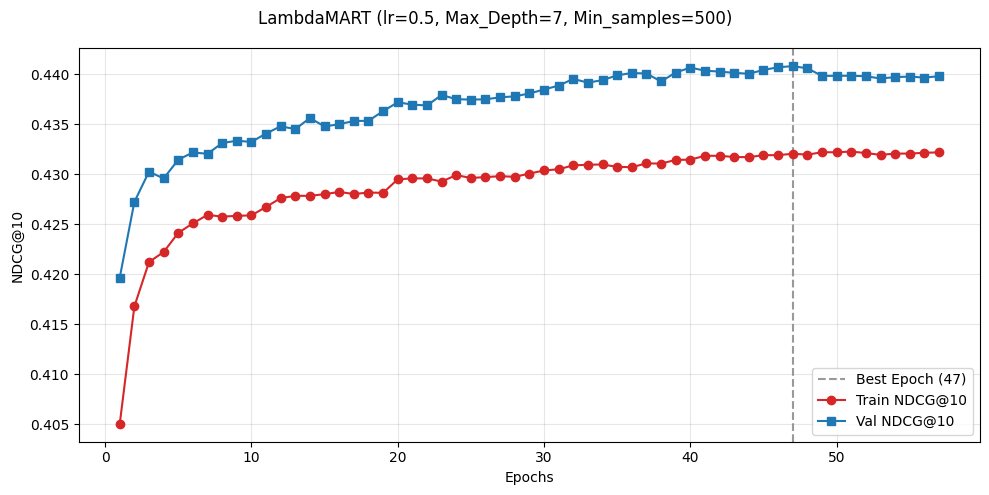

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=7, Min_samples=500)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=7, Min_samples=500)
──────────────────────────────
  NDCG@1  : 0.4361
  NDCG@3  : 0.4168
  NDCG@5  : 0.4202
  NDCG@10 : 0.4324


- As we discussed, because the learning rate is very low, It is onder fitting.
- Let us try increasing it to **0.3**.

## learning rate = 0.3

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.3,
    max_depth=7,
    min_samples_leaf=500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.3000 | η·α*: 0.0900 | Train NDCG@10: 0.4051 | Val NDCG@10: 0.4197  <- best
Tree 002 | α*: 0.0886 | η·α*: 0.0266 | Train NDCG@10: 0.4244 | Val NDCG@10: 0.4302  <- best
Tree 003 | α*: 0.0880 | η·α*: 0.0264 | Train NDCG@10: 0.4272 | Val NDCG@10: 0.4361  <- best
Tree 004 | α*: 0.0509 | η·α*: 0.0153 | Train NDCG@10: 0.4283 | Val NDCG@10: 0.4382  <- best
Tree 005 | α*: 0.0375 | η·α*: 0.0113 | Train NDCG@10: 0.4304 | Val NDCG@10: 0.4393  <- best
Tree 006 | α*: 0.2004 | η·α*: 0.0601 | Train NDCG@10: 0.4329 | Val NDCG@10: 0.4422  <- best
Tree 007 | α*: 0.1548 | η·α*: 0.0464 | Train NDCG@10: 0.4352 | Val NDCG@10: 0.4407
Tree 008 | α*: 0.1990 | η·α*: 0.0597 | Train NDCG@10: 0.4366 | Val NDCG@10: 0.4449  <- best
Tree 009 | α*: 0.1709 | η·α*: 0.0513 | Train NDCG@10: 0.4384 | Val NDCG@10: 0.4467  <- best
Tree 010 | α*: 0.3213 | η·α*: 0.0964 | Train NDCG@10: 0.4386 | Val NDCG@10: 0.4481  <- best
Tree 011 | α*: 0.4591 | η·α*: 0.1377 | Train NDCG@10: 0.4411 | Val NDCG@10: 0.4513  <- be

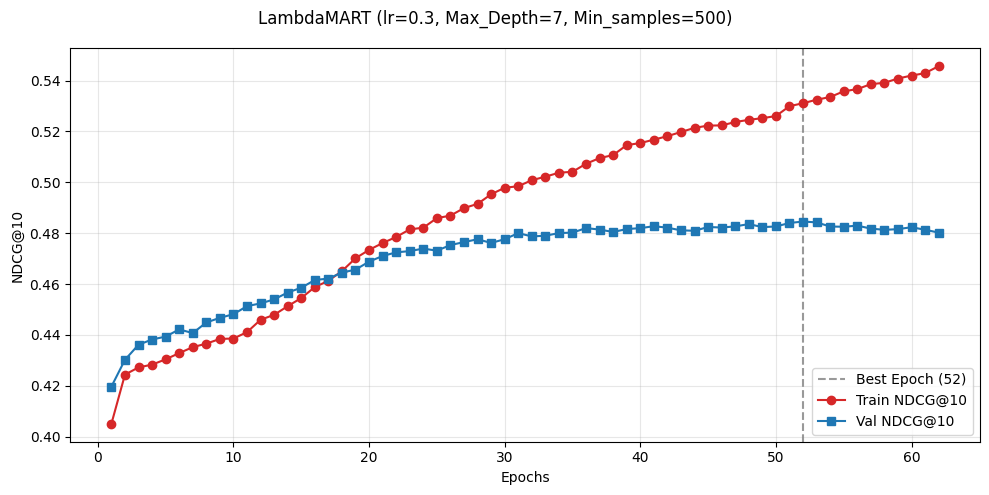

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.3, Max_Depth=7, Min_samples=500)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.3, Max_Depth=7, Min_samples=500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.3, Max_Depth=7, Min_samples=500)
──────────────────────────────
  NDCG@1  : 0.4650
  NDCG@3  : 0.4433
  NDCG@5  : 0.4496
  NDCG@10 : 0.4713


- This is best result we got till now.
- We solved the problem of underfitting and we can see a slight overfitting here.
- Let us try to find a point between `(0.1,0.3)`.

## learning rate = 0.2

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=7,
    min_samples_leaf=500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.2000 | η·α*: 0.0400 | Train NDCG@10: 0.4051 | Val NDCG@10: 0.4197  <- best
Tree 002 | α*: 0.1076 | η·α*: 0.0215 | Train NDCG@10: 0.4251 | Val NDCG@10: 0.4333  <- best
Tree 003 | α*: 0.0299 | η·α*: 0.0060 | Train NDCG@10: 0.4260 | Val NDCG@10: 0.4327
Tree 004 | α*: 0.0450 | η·α*: 0.0090 | Train NDCG@10: 0.4293 | Val NDCG@10: 0.4372  <- best
Tree 005 | α*: 0.0261 | η·α*: 0.0052 | Train NDCG@10: 0.4295 | Val NDCG@10: 0.4367
Tree 006 | α*: 0.0217 | η·α*: 0.0043 | Train NDCG@10: 0.4293 | Val NDCG@10: 0.4371
Tree 007 | α*: 0.0183 | η·α*: 0.0037 | Train NDCG@10: 0.4295 | Val NDCG@10: 0.4371
Tree 008 | α*: 0.0138 | η·α*: 0.0028 | Train NDCG@10: 0.4297 | Val NDCG@10: 0.4373  <- best
Tree 009 | α*: 0.0108 | η·α*: 0.0022 | Train NDCG@10: 0.4299 | Val NDCG@10: 0.4372
Tree 010 | α*: 0.0370 | η·α*: 0.0074 | Train NDCG@10: 0.4313 | Val NDCG@10: 0.4373
Tree 011 | α*: 0.0660 | η·α*: 0.0132 | Train NDCG@10: 0.4322 | Val NDCG@10: 0.4402  <- best
Tree 012 | α*: 0.0482 | η·α*: 0.0096 | Tra

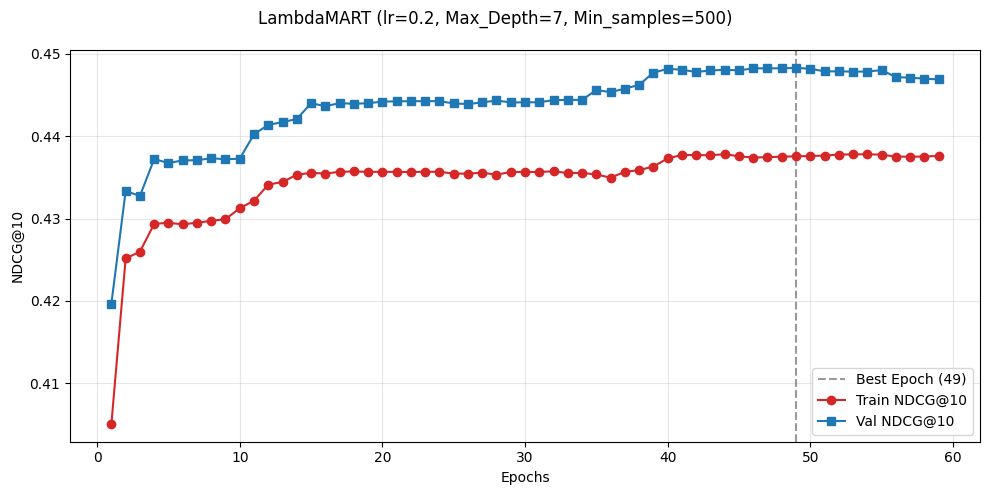

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.2, Max_Depth=7, Min_samples=500)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.2, Max_Depth=7, Min_samples=500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.2, Max_Depth=7, Min_samples=500)
──────────────────────────────
  NDCG@1  : 0.4462
  NDCG@3  : 0.4219
  NDCG@5  : 0.4250
  NDCG@10 : 0.4359


- The model is underfitting again. The result is worse.
- Let us see if increasing learning rate further will help us.

## learning rate = 0.4

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.4,
    max_depth=7,
    min_samples_leaf=500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.4000 | η·α*: 0.1600 | Train NDCG@10: 0.4051 | Val NDCG@10: 0.4197  <- best
Tree 002 | α*: 0.2036 | η·α*: 0.0815 | Train NDCG@10: 0.4245 | Val NDCG@10: 0.4352  <- best
Tree 003 | α*: 0.2164 | η·α*: 0.0866 | Train NDCG@10: 0.4291 | Val NDCG@10: 0.4395  <- best
Tree 004 | α*: 0.4230 | η·α*: 0.1692 | Train NDCG@10: 0.4353 | Val NDCG@10: 0.4507  <- best
Tree 005 | α*: 0.3664 | η·α*: 0.1466 | Train NDCG@10: 0.4408 | Val NDCG@10: 0.4515  <- best
Tree 006 | α*: 0.3248 | η·α*: 0.1299 | Train NDCG@10: 0.4447 | Val NDCG@10: 0.4584  <- best
Tree 007 | α*: 0.3958 | η·α*: 0.1583 | Train NDCG@10: 0.4475 | Val NDCG@10: 0.4573
Tree 008 | α*: 0.5864 | η·α*: 0.2346 | Train NDCG@10: 0.4508 | Val NDCG@10: 0.4619  <- best
Tree 009 | α*: 0.6684 | η·α*: 0.2673 | Train NDCG@10: 0.4582 | Val NDCG@10: 0.4639  <- best
Tree 010 | α*: 0.5700 | η·α*: 0.2280 | Train NDCG@10: 0.4625 | Val NDCG@10: 0.4646  <- best
Tree 011 | α*: 0.7514 | η·α*: 0.3006 | Train NDCG@10: 0.4687 | Val NDCG@10: 0.4704  <- be

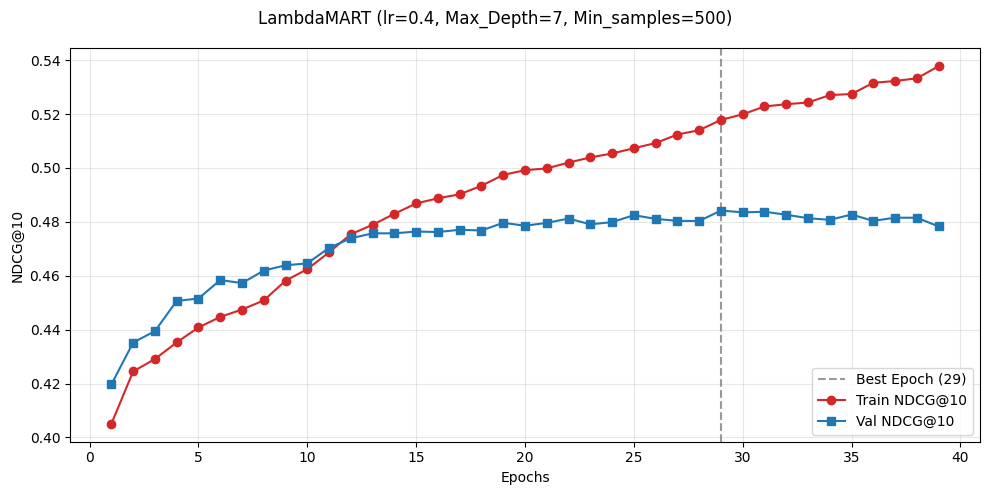

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.4, Max_Depth=7, Min_samples=500)")

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.4, Max_Depth=7, Min_samples=500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.4, Max_Depth=7, Min_samples=500)
──────────────────────────────
  NDCG@1  : 0.4510
  NDCG@3  : 0.4324
  NDCG@5  : 0.4412
  NDCG@10 : 0.4637


In [ ]:
# 1. Define a function that returns a fresh model for each fold/seed
def get_lambdamart_model():
    return LambdaMART(
        n_estimators=100,
        learning_rate=0.3,
        max_depth=7,
        min_samples_leaf=500,
        k=10,
        patience=10,
        use_optimal_line_search=True
    )

# 2. Create a custom loader wrapper to apply our query limits
def custom_mslr_loader(base_path, fold_num, batch_size):
    return load_fold(
        base_path=base_path,
        fold_num=fold_num,
        batch_size=batch_size,
        num_train_queries=1500,
        num_val_queries=500,
        num_test_queries=500
    )

# 3. Run the 5-Fold Cross-Validation
results = cross_fold_eval_lambdamart(
    model_fn=get_lambdamart_model,
    base_path=DATA_PATH,
    data_loader_fn=custom_mslr_loader,
    folds=(1, 2, 3, 4, 5),
    seeds=[42],
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    verbose=False
)


═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 1501 train | 501 val | 501 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4650 ± 0.0000
  NDCG@3  : 0.4433 ± 0.0000
  NDCG@5  : 0.4496 ± 0.0000
  NDCG@10 : 0.4713 ± 0.0000

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════
  [Fold 2] Loading train split...


  [Fold 2] Loading val split...


...

  [Fold 4] Loading test split...


  Fold 4: 1501 train | 501 val | 501 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4440 ± 0.0000
  NDCG@3  : 0.4351 ± 0.0000
  NDCG@5  : 0.4483 ± 0.0000
  NDCG@10 : 0.4647 ± 0.0000

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════
  [Fold 5] Loading train split...


  [Fold 5] Loading val split...


  [Fold 5] Loading test split...


  Fold 5: 1501 train | 501 val | 501 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4752 ± 0.0000
  NDCG@3  : 0.4625 ± 0.0000
  NDCG@5  : 0.4647 ± 0.0000
  NDCG@10 : 0.4801 ± 0.0000

═══════════════════════════════════════════════════════
  OVERALL RESULTS (LAMBDAMART)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4567 ± 0.0116
  NDCG@3  : 0.4417 ± 0.0128
  NDCG@5  : 0.4492 ± 0.0097
  NDCG@10 : 0.4671 ± 0.0079
═══════════════════════════════════════════════════════

